In [22]:
import os
import shutil
import subprocess
import time
import numpy as np
from matplotlib import pyplot as plt


In [23]:
tspan_ini_ini=0
dt_ini_ini=0.0001
tspan_ini = 0
dt_ini = 0.001
dt = 0.0001
dt_maxi = 0.1
tspan_maxi = 10

t_thermal=5
Cthermal=0.45
dt_thermal=0.001
#tspan = 100

R0 = 40
tspan = (R0**2/2)*2
print(tspan)

tspan=10
tspan_maxi=max(tspan,tspan_maxi)

N = round(tspan_ini/dt_ini)
N = N + round((tspan_maxi-tspan_ini)/dt)
N = N + round((tspan-tspan_maxi)/dt_maxi) + 10
Cs = np.zeros(N)
ts = np.zeros(N)

1600.0


../../../1D/.saves/26_3_18_A_step_small/fileCin.dat


Text(0.5, 0, 't')

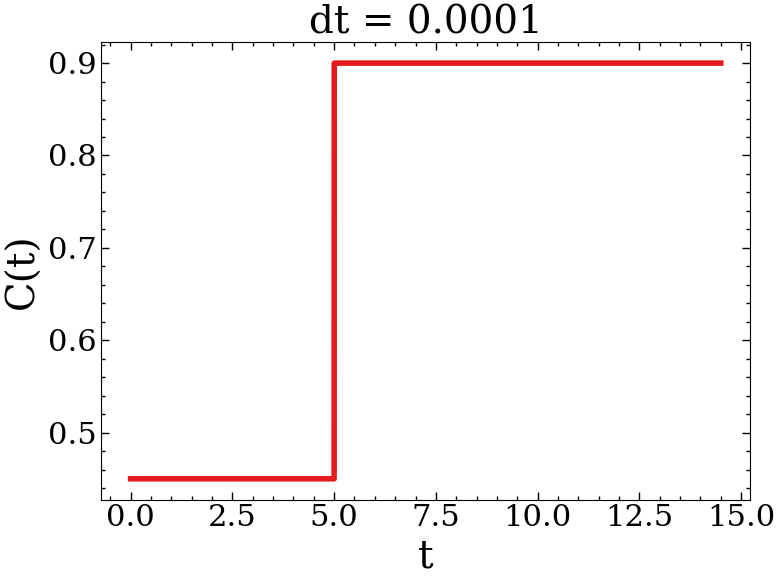

In [ ]:
# Create evolution directory

Cbar = 0.9
A = 0
T = -1
simul_name = f"25_11_10_B_coarsening_{A}_{T}_{Cbar}_1"
D0=6
simul_name = f"25_11_10_B_pinching_{A}_{T}_{Cbar}_{D0}_bis"
simul_name = f"25_11_12_A_pinching_{A}_{T}_{Cbar}_{D0}"
simul_name = "25_11_12_test"
simul_name = "25_11_17_A_coarsening_3_25_0_0"
simul_name = f"25_10_30_B_{A}_{T}_{Cbar}"
simul_name = f"26_1_26_A_{A}_{T}_{Cbar}"
simul_name = f"26_3_19_A_up_down"

file_simul = "../../1D/.saves/" + simul_name + "/" 
name = "fileCin.dat"
dir = "../" + file_simul + name

print(dir)
if not os.path.isdir("../"+file_simul):
    os.makedirs("../"+file_simul)
f = open(dir, "w")



ts[0] = 0
Cs[0] = Cthermal
for i in np.arange(1,N):
    if ts[i-1] < t_thermal:
        ts[i] = ts[i-1]+dt_thermal
        #Cs[i] = Cbar+(Cbar-Cthermal)/t_thermal*(ts[i-1]-t_thermal)
        Cs[i] = Cthermal
    else:
        if ts[i-1]-t_thermal < tspan_ini_ini:
            ts[i] = ts[i-1]+dt_ini_ini
        elif ts[i-1]-t_thermal < tspan_ini:
            ts[i] = ts[i-1]+dt_ini
        elif ts[i-1]-t_thermal < tspan_maxi:
            ts[i] = ts[i-1]+dt
        else:
            ts[i] = ts[i-1]+dt_maxi
        if T > 0:
            Cs[i] = Cbar - A*np.sin(2*np.pi*ts[i]/T)
        else:
            Cs[i] = Cbar
    #Cs[i] = Cbar + A*np.sin(2*np.pi*ts[i]/T) + 0.2*A*np.sin(4*np.pi*ts[i]/T)
    #Cs[i] = Cbar
    """
    if np.sin(2*np.pi*ts[i]/T) > 0:
        Cs[i] = Cbar + A
    else:
        Cs[i] = Cbar - A

    #Cs[i] = Cbar
    """
    
    f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
f.close()

plt.plot(ts, Cs)
plt.title("dt = " + str(dt))
plt.ylabel("C(t)")
plt.xlabel("t")
#plt.xlim(0,50)

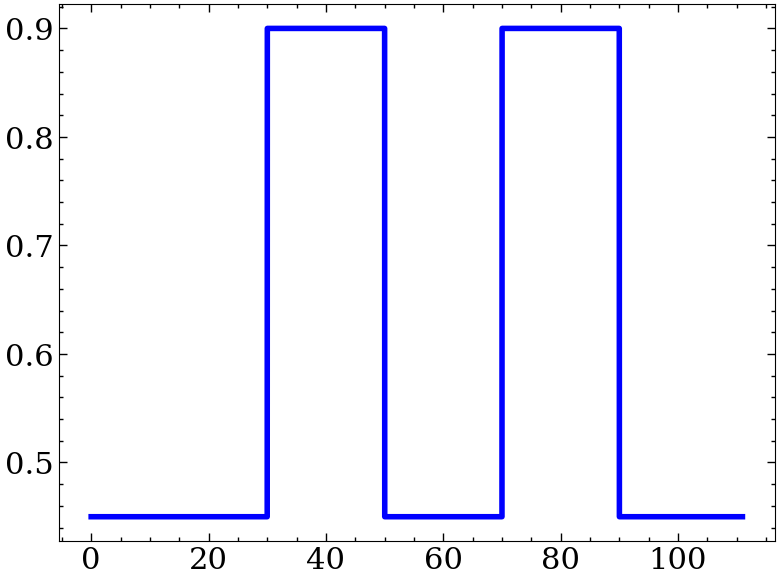

In [ ]:
simul_name = f"26_3_19_B_step"
file_simul = "../../1D/.saves/" + simul_name + "/" 
name = "fileCin.dat"
dir = "../" + file_simul + name
if not os.path.isdir("../"+file_simul):
    os.makedirs("../"+file_simul)
f = open(dir, "w")

t_thermal=30
dt=0.01
dt_thermal=0.01
tspan=100

Cs = np.zeros(int(t_thermal/dt_thermal+tspan/dt))
ts = np.zeros(int(t_thermal/dt_thermal+tspan/dt))
Cs[0]=Cthermal

i=1
# Thermalization
tmax = t_thermal
while ts[i-1]<t_thermal:
    ts[i] = ts[i-1]+dt_thermal
    Cs[i] = Cthermal
    f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
    i=i+1
# Step/antistep
delt1=20
delt2=20
Nsteps=2
for n in np.arange(0,Nsteps):
    tmax = tmax+delt1
    while ts[i-1]<tmax:
        Cs[i]=Cbar
        ts[i] = ts[i-1]+dt
        f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
        i=i+1
    tmax = tmax+delt2
    while ts[i-1]<tmax:
        Cs[i]=Cthermal
        ts[i] = ts[i-1]+dt
        f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
        i=i+1

tmax = tmax+1
while ts[i-1]<tmax:
    Cs[i]=Cthermal
    ts[i] = ts[i-1]+dt
    f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
    i=i+1
f.close()
plt.plot(ts[:i-1],Cs[:i-1],color='blue')
#plt.xlim(left=29.9)

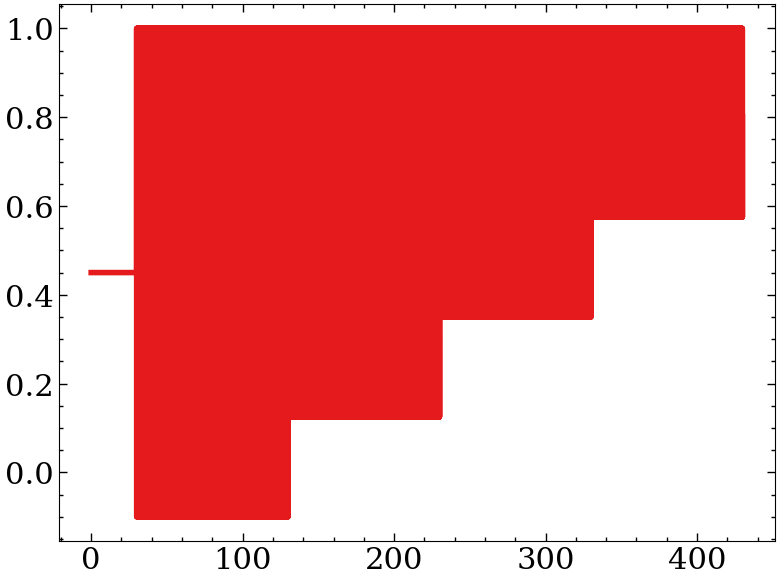

In [ ]:
Cthermal = 0.45
Cbar=0.9    # Cbarmax
A = 0.1     # Max 
T=0.1   # Fast timescale
delt = 100   # Slow timescale
Nsteps=4    # Number of stairs


simul_name = f"26_3_19_B_stairtris"
file_simul = "../../1D/.saves/" + simul_name + "/" 
name = "fileCin.dat"
dir = "../" + file_simul + name
if not os.path.isdir("../"+file_simul):
    os.makedirs("../"+file_simul)
f = open(dir, "w")

# Build the average value stair
t_thermal=30
dt=0.001
dt_thermal=0.01
tspan=100

Cs = np.zeros(int(t_thermal/dt_thermal+(delt*(Nsteps+1))/dt)+1)
ts = np.zeros(int(t_thermal/dt_thermal+(delt*(Nsteps+1))/dt)+1)
Cs[0]=Cthermal

i=1
Cs[0]=Cthermal
# Thermalization
tmax = t_thermal
while ts[i-1]<t_thermal:
    ts[i] = ts[i-1]+dt_thermal
    Cs[i] = Cthermal
    f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
    i=i+1
# Step/antistep
Cstep=Cthermal
for n in np.arange(0,Nsteps):
    Cstep = Cthermal+n*(Cbar-Cthermal)/Nsteps
    tmax = tmax+delt
    while ts[i-1]<tmax:
        ts[i] = ts[i-1]+dt
        Cs[i]=Cstep+(1-Cstep)*np.sin(2*np.pi*ts[i]/T)   # Add the FAST oscillation
        f.write(str(ts[i]) + " " + str(Cs[i]) + "\n")
        i=i+1


plt.plot(ts[:i],Cs[:i])
#plt.xlim(40,40.1)

In [ ]:
print(Cs[0])

0.0


In [ ]:
max(ts)

5.06609999999985

In [ ]:
CMD = "./datainit 256 0.1 'ppp'"
p = subprocess.call(CMD.split(), cwd="../.bin")
print(p)

FileNotFoundError: [Errno 2] No such file or directory: '../.bin'